In [ ]:
from fastprogress import *
import time

import numpy as np

In [ ]:
for i in progress_bar(range(30)): time.sleep(0.02)

div((progress((),{'max': 30, 'value': 30}), ' ', '100.00% [30/30 00:01<00:00]'),{})

In [ ]:
for i in (mb := master_bar(range(5))):
    mb.write(['epoch', 'train_loss', 'valid_loss'], table=True) if i==0 else None
    mb.main_bar.comment = f'first bar stat'
    for j in mb.progress(range(10)):
        time.sleep(0.02)
        mb.child.comment = f'second bar stat'
    mb.write([str(i), f'{1/(i+1):.3f}', f'{1.2/(i+1):.3f}'], table=True)

epoch,train_loss,valid_loss
0,1.000,1.200
1,0.500,0.600
2,0.333,0.400
3,0.250,0.300
4,0.200,0.240


In [ ]:
class Img:
    def __init__(self, data): self.data = data
    def show(self, ax, title=None):
        ax.imshow(self.data)
        if title: ax.set_title(title)

div((),{})

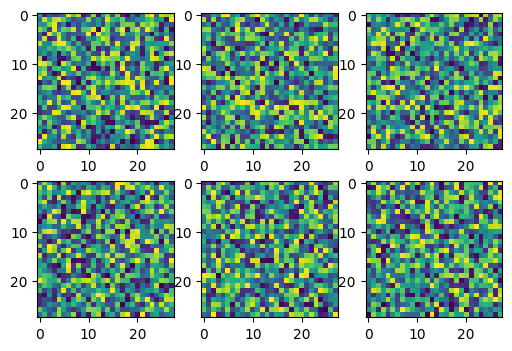

In [ ]:
for i in (mb := master_bar(range(5))):
    imgs = [Img(np.random.rand(28,28)) for _ in range(6)]
    mb.show_imgs(imgs, cols=3, imgsize=2)
    time.sleep(0.2)

In [ ]:
class Training:
    def __init__(self): self.epoch, self.train_losses, self.valid_losses = 0, [], []

    def step(self):
        tl = 1.0/(self.epoch+1) + np.random.rand()*0.1
        vl = 1.2/(self.epoch+1) + np.random.rand()*0.1
        self.train_losses.append((self.epoch, tl))
        self.valid_losses.append((self.epoch, vl))
        self.epoch += 1
    
    @property
    def graphs(self): return [list(zip(*self.train_losses)), list(zip(*self.valid_losses))]

    @property
    def stats(self):
        return [str(self.epoch-1), f'{self.train_losses[-1][1]:.3f}', f'{self.valid_losses[-1][1]:.3f}']

epoch,train_loss,valid_loss
0,1.023,1.215
1,0.599,0.676
2,0.399,0.492
3,0.328,0.392
4,0.235,0.326


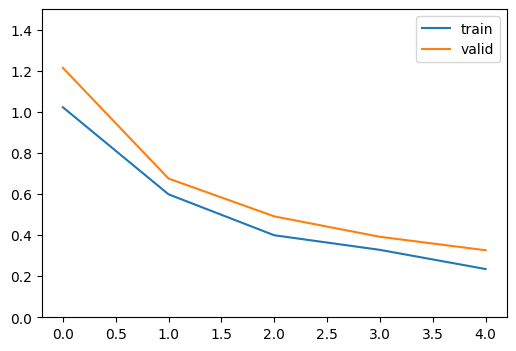

In [ ]:
trainer = Training()
for i in (mb:=master_bar(range(5))):
    mb.write(['epoch', 'train_loss', 'valid_loss'], table=True) if i==0 else None
    trainer.step()
    mb.update_graph(trainer.graphs, y_bounds=(0,1.5))
    mb.write(trainer.stats, table=True)
    time.sleep(0.3)

In [ ]:
master_bar,progress_bar = force_console_behavior()

In [ ]:
for i in progress_bar(range(50)): time.sleep(0.02)

 |----------------------------------------| 0.00% [0/50 00:00<?]

 |----------------------------------------| 2.00% [1/50 00:00<00:04]

 |█---------------------------------------| 4.00% [2/50 00:00<00:04]

 |██--------------------------------------| 6.00% [3/50 00:00<00:04]

 |███-------------------------------------| 8.00% [4/50 00:00<00:03]

...

 |█████████████████████████████████-------| 84.00% [42/50 00:02<00:00]

 |███████████████████████████████████-----| 88.00% [44/50 00:02<00:00]

 |████████████████████████████████████----| 92.00% [46/50 00:03<00:00]

 |██████████████████████████████████████--| 96.00% [48/50 00:03<00:00]

 |████████████████████████████████████████| 100.00% [50/50 00:03<00:00]

In [ ]:
for i in (mb := master_bar(range(5))):
    for j in mb.progress(range(10)):
        time.sleep(0.02)
        mb.child.comment = f'second bar stat'
    mb.main_bar.comment = f'first bar stat'
    mb.write(f'Finished loop {i}.')

Epoch 1/5 : |----------------------------------------| 0.00% [0/10 00:00<?]

Epoch 1/5 : |████------------------------------------| 10.00% [1/10 00:00<00:00... second bar stat]

Epoch 1/5 : |████████--------------------------------| 20.00% [2/10 00:00<00:00... second bar stat]

Epoch 1/5 : |████████████----------------------------| 30.00% [3/10 00:00<00:00... second bar stat]

Epoch 1/5 : |████████████████------------------------| 40.00% [4/10 00:00<00:00... second bar stat]

...

Epoch 5/5 : |████████████████------------------------| 40.00% [4/10 00:00<00:00... second bar stat]

Epoch 5/5 : |████████████████████--------------------| 50.00% [5/10 00:00<00:00... second bar stat]

Epoch 5/5 : |████████████████████████████████--------| 80.00% [8/10 00:00<00:00... second bar stat]

Epoch 5/5 : |███████████████████████████████████████| 100.00% [10/10 00:00<00:00... second bar stat]

Finished loop 4.


div((),{})

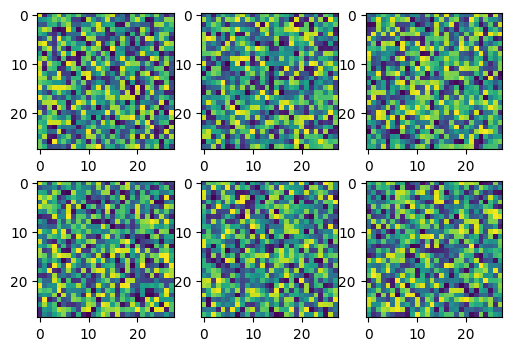

In [ ]:
for i in (mb := master_bar(range(5))):
    imgs = [Img(np.random.rand(28,28)) for _ in range(6)]
    for _ in mb.progress(range(8)): time.sleep(0.05)
    mb.show_imgs(imgs, cols=3, imgsize=2)